# Load Data


In [158]:
from sklearn.datasets import fetch_20newsgroups

In [159]:
data = fetch_20newsgroups()

In [160]:
import pandas as pd

In [161]:
df = pd.DataFrame(data.data[:20], columns=["text"])
df.head()

,text
0,From: lerxst@wam.umd.edu (where's my thing)\nS...
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...


In [162]:
for i in range(5):
    print(df['text'][i])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----





From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.wa

In [163]:
df['text'] = df['text'].str.lower()
df.head()

,text
0,from: lerxst@wam.umd.edu (where's my thing)\ns...
1,from: guykuo@carson.u.washington.edu (guy kuo)...
2,from: twillis@ec.ecn.purdue.edu (thomas e will...
3,from: jgreen@amber (joe green)\nsubject: re: w...
4,from: jcm@head-cfa.harvard.edu (jonathan mcdow...


# Cleaning Text Data


In [164]:
import re

## Remove HTML Tags


In [165]:
html_regex = re.compile(r'<.*?>')
def remove_html(text):
    return re.sub(html_regex, '', text)
df['text'] = df['text'].apply(remove_html)
df.head()

,text
0,from: lerxst@wam.umd.edu (where's my thing)\ns...
1,from: guykuo@carson.u.washington.edu (guy kuo)...
2,from: twillis@ec.ecn.purdue.edu (thomas e will...
3,from: jgreen@amber (joe green)\nsubject: re: w...
4,from: jcm@head-cfa.harvard.edu (jonathan mcdow...


## Remove Links


In [166]:
link_regex = re.compile(r'https?://\S+|www\.\S+')
def remove_links(text):
    return re.sub(link_regex, '', text)
df['text'] = df['text'].apply(remove_links)
df.head()

,text
0,from: lerxst@wam.umd.edu (where's my thing)\ns...
1,from: guykuo@carson.u.washington.edu (guy kuo)...
2,from: twillis@ec.ecn.purdue.edu (thomas e will...
3,from: jgreen@amber (joe green)\nsubject: re: w...
4,from: jcm@head-cfa.harvard.edu (jonathan mcdow...


## Remove Punctuation


In [167]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

### Punctuation Removal with Regex


In [168]:
punc_re = re.compile(r"[0-9{}]".format(re.escape(punctuation)))
punc_re

re.compile(r'[0-9!"\#\$%\&\'\(\)\*\+,\-\./:;<=>\?@\[\\\]\^_`\{\|\}\~]',
re.UNICODE)

### Mail regex


In [169]:
mail_re = re.compile('[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-7729/135190596.py:1: SyntaxWarning: invalid escape sequence '\.'
  mail_re = re.compile('[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')


In [170]:
import random

random_num = int(random.random() * 1000000000)
random_num

654362923

In [171]:
def remove_puns(text):
    mails = mail_re.findall(text)
    for mail in mails:
        text = text.replace(mail,f"{random_num}")
    clean = punc_re.sub('',text)
    for i,mail in enumerate(mails):
        clean = clean.replace(f"{random_num}",mail)
    return clean

In [172]:
df['text'] = df['text'].apply(remove_puns)
df.head()

,text
0,from wheres my thing\nsubject what car is thi...
1,from guy kuo\nsubject si clock poll final ca...
2,from thomas e willis\nsubject pb questions\no...
3,from jgreenamber joe green\nsubject re weitek ...
4,from jonathan mcdowell\nsubject re shuttle la...


## Stop Words


In [173]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stopword = stopwords.words('english')
stopword

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [174]:
def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    return " ".join(new_text)

In [175]:
str = "the asdf asdf cxzv asdf"
remove_stopwords(str)

' asdf asdf cxzv asdf'

In [176]:
df['text'] = df['text'].apply(remove_stopwords)
df.head()

,text
0,wheres thing subject car nntppostinghost ...
1,guy kuo subject si clock poll final call summ...
2,thomas e willis subject pb questions organiza...
3,jgreenamber joe green subject weitek p organ...
4,jonathan mcdowell subject shuttle launch que...


In [177]:
print(df['text'][0])

 wheres  thing subject  car   nntppostinghost racwamumdedu organization university  maryland college park lines   wondering  anyone   could enlighten    car  saw   day    door sports car looked     late  early    called  bricklin  doors  really small  addition  front bumper  separate   rest   body     know  anyone  tellme  model name engine specs years  production   car  made history  whatever info     funky looking car please email thanks il brought     neighborhood lerxst


## Fix Contractions


In [178]:
!pip install contractions

In [179]:
import contractions


df['text'] = df['text'].apply(contractions.fix)

print(df['text'].iloc[0])

 where is  thing subject  car   nntppostinghost racwamumdedu organization university  maryland college park lines   wondering  anyone   could enlighten    car  saw   day    door sports car looked     late  early    called  bricklin  doors  really small  addition  front bumper  separate   rest   body     know  anyone  tellme  model name engine specs years  production   car  made history  whatever info     funky looking car please email thanks il brought     neighborhood lerxst


## Stemming


## POS

Here i will use a model to classify the words type (verbe, nom, adjectif, etc.)
than do stemming for verbs only

In [180]:
from transformers import pipeline
# Create the PoS tagging pipeline
pos_pipeline = pipeline(
    task="token-classification",
    model="vblagoje/bert-english-uncased-finetuned-pos",
    aggregation_strategy="simple"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: vblagoje/bert-english-uncased-finetuned-pos
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [181]:
df.head()

,text
0,where is thing subject car nntppostinghos...
1,guy kuo subject si clock poll final call summ...
2,thomas e willis subject pb questions organiza...
3,jgreenamber joe green subject weitek p organ...
4,jonathan mcdowell subject shuttle launch que...


In [182]:
import numpy as np
def get_pos_tags(sentence):
    pos_tags = pos_pipeline(sentence)
    return pos_tags
# do for all rows
pos_tags = []
for i in range(len(df)):
    pos = get_pos_tags(df['text'].iloc[i])
    sub_pos = []
    for token in pos:
        sub_pos.append({token['word']: token['entity_group']})
    pos_tags.append(sub_pos)

In [183]:
pos_tags[0]

[{'where': 'ADV'},
 {'is': 'AUX'},
 {'thing subject car': 'NOUN'},
 {'nntpp': 'X'},
 {'##ost': 'VERB'},
 {'##ing': 'NOUN'},
 {'##host': 'X'},
 {'rac': 'NOUN'},
 {'##wamumdedu': 'X'},
 {'organization': 'NOUN'},
 {'university maryland college park': 'PROPN'},
 {'lines': 'NOUN'},
 {'wondering': 'VERB'},
 {'anyone': 'PRON'},
 {'could': 'AUX'},
 {'enlighten': 'VERB'},
 {'car saw day door sports car': 'NOUN'},
 {'looked': 'VERB'},
 {'late': 'ADJ'},
 {'early': 'ADV'},
 {'called': 'VERB'},
 {'bricklin doors': 'PROPN'},
 {'really': 'ADV'},
 {'small': 'ADJ'},
 {'addition': 'NOUN'},
 {'front': 'ADJ'},
 {'bumper': 'NOUN'},
 {'separate': 'ADJ'},
 {'rest body': 'NOUN'},
 {'know': 'VERB'},
 {'anyone': 'PRON'},
 {'tell': 'VERB'},
 {'##me': 'ADJ'},
 {'model name engine spec': 'NOUN'},
 {'##s': 'ADP'},
 {'years production car': 'NOUN'},
 {'made': 'VERB'},
 {'history': 'NOUN'},
 {'whatever': 'DET'},
 {'info': 'NOUN'},
 {'funky': 'ADJ'},
 {'looking': 'VERB'},
 {'car': 'NOUN'},
 {'please': 'INTJ'},
 {'emai

In [184]:
print(df['text'][0])

 where is  thing subject  car   nntppostinghost racwamumdedu organization university  maryland college park lines   wondering  anyone   could enlighten    car  saw   day    door sports car looked     late  early    called  bricklin  doors  really small  addition  front bumper  separate   rest   body     know  anyone  tellme  model name engine specs years  production   car  made history  whatever info     funky looking car please email thanks il brought     neighborhood lerxst


In [185]:
len(pos_tags)

20

In [186]:
df['pos_tags'] = pos_tags
df['pos_tags'].head()

,pos_tags
0,"[{'where': 'ADV'}, {'is': 'AUX'}, {'thing subj..."
1,"[{'guy kuo': 'PROPN'}, {'subject si clock poll..."
2,"[{'thomas e willis': 'PROPN'}, {'subject pb qu..."
3,"[{'jgreenamber joe green': 'PROPN'}, {'subject..."
4,"[{'jonathan mcdowell': 'PROPN'}, {'subject shu..."


In [187]:
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.lancaster import LancasterStemmer
from nltk.stem.regexp import RegexpStemmer as regexp_stemmer
snowball_stemmer = SnowballStemmer('english')
stemmer = PorterStemmer()
lancaster = LancasterStemmer()
regex_stem = regexp_stemmer('ing$|s$|e$|able$', min=4)
words = "he was a police officer and he was running after the thief"
snow = [snowball_stemmer.stem(word) for word in words.split()]
port = [stemmer.stem(word) for word in words.split()]
lancaster_stem = [lancaster.stem(word) for word in words.split()]
reg = [regex_stem.stem(word) for word in words.split()]
print(f''' 
      PorterStemmer : {port}
      
      SnowballStemmer : {snow}
      
      LancasterStemmer : {lancaster_stem}
      
      RegexpStemmer : {reg}
      
      ''')

 
      PorterStemmer : ['he', 'wa', 'a', 'polic', 'offic', 'and', 'he', 'wa', 'run', 'after', 'the', 'thief']
      
      SnowballStemmer : ['he', 'was', 'a', 'polic', 'offic', 'and', 'he', 'was', 'run', 'after', 'the', 'thief']
      
      LancasterStemmer : ['he', 'was', 'a', 'pol', 'off', 'and', 'he', 'was', 'run', 'aft', 'the', 'thief']
      
      RegexpStemmer : ['he', 'was', 'a', 'polic', 'officer', 'and', 'he', 'was', 'runn', 'after', 'the', 'thief']
      
      


In [188]:
df.head()

,text,pos_tags
0,where is thing subject car nntppostinghos...,"[{'where': 'ADV'}, {'is': 'AUX'}, {'thing subj..."
1,guy kuo subject si clock poll final call summ...,"[{'guy kuo': 'PROPN'}, {'subject si clock poll..."
2,thomas e willis subject pb questions organiza...,"[{'thomas e willis': 'PROPN'}, {'subject pb qu..."
3,jgreenamber joe green subject weitek p organ...,"[{'jgreenamber joe green': 'PROPN'}, {'subject..."
4,jonathan mcdowell subject shuttle launch que...,"[{'jonathan mcdowell': 'PROPN'}, {'subject shu..."


In [189]:
# now steeming the verbs in pos_tags and return in to df
def stem_verbs(arr):
    stemmer = PorterStemmer()
    stemmed_arr = []
    for obj in arr:
        stemmed_obj = {}
        for k, v in obj.items():
            if v == "VERB":
                stemmed_obj[stemmer.stem(k)] = v
            else:
                stemmed_obj[k] = v
        stemmed_arr.append(stemmed_obj)
    return stemmed_arr

df['pos_tags_stemmed'] = df['pos_tags'].apply(stem_verbs)
df.head()

,text,pos_tags,pos_tags_stemmed
0,where is thing subject car nntppostinghos...,"[{'where': 'ADV'}, {'is': 'AUX'}, {'thing subj...","[{'where': 'ADV'}, {'is': 'AUX'}, {'thing subj..."
1,guy kuo subject si clock poll final call summ...,"[{'guy kuo': 'PROPN'}, {'subject si clock poll...","[{'guy kuo': 'PROPN'}, {'subject si clock poll..."
2,thomas e willis subject pb questions organiza...,"[{'thomas e willis': 'PROPN'}, {'subject pb qu...","[{'thomas e willis': 'PROPN'}, {'subject pb qu..."
3,jgreenamber joe green subject weitek p organ...,"[{'jgreenamber joe green': 'PROPN'}, {'subject...","[{'jgreenamber joe green': 'PROPN'}, {'subject..."
4,jonathan mcdowell subject shuttle launch que...,"[{'jonathan mcdowell': 'PROPN'}, {'subject shu...","[{'jonathan mcdowell': 'PROPN'}, {'subject shu..."


In [190]:
df['text'] = df['pos_tags_stemmed'].apply(lambda x: " ".join([list(d.keys())[0] for d in x]))
df['text'][0]

'where is thing subject car nntpp ##ost ##ing ##host rac ##wamumdedu organization university maryland college park lines wonder anyone could enlighten car saw day door sports car look late early call bricklin doors really small addition front bumper separate rest body know anyone tell ##me model name engine spec ##s years production car made history whatever info funky look car please email thanks il brought neighborhood lerxst'

## Lemmatization


In [191]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [192]:
from nltk.stem import WordNetLemmatizer
# Intilize Lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

wordnet_lemmatizer.lemmatize('looked', pos='v')

'look'

In [194]:
def lemmatize(text):
    lem = [wordnet_lemmatizer.lemmatize(word,pos='v') for word in text.split()]
    return lem

In [195]:
df['text'] = df['text'].apply(lemmatize)

In [197]:
df['text'] = df['text'].apply(lambda x: " ".join(x))

In [198]:
df['text'][0]

'where be thing subject car nntpp ##ost ##ing ##host rac ##wamumdedu organization university maryland college park line wonder anyone could enlighten car saw day door sport car look late early call bricklin doors really small addition front bumper separate rest body know anyone tell ##me model name engine spec ##s years production car make history whatever info funky look car please email thank il bring neighborhood lerxst'

TODO: Text Representation

- [ ] Bag of Words
- [ ] TF-IDF
- [ ] Word Embeddings


# Text Representation


## Bag of Words


In [199]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
import string

In [200]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['text'])

vectorizer.get_feature_names_out()

array(['ab', 'able', 'abraham', ..., 'ze', 'zoom', 'zyk'], dtype=object)

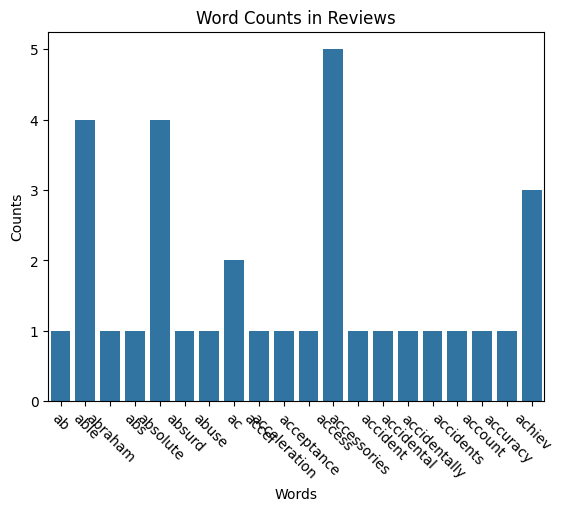

In [201]:
# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

sns.barplot(x=words[:20], y=word_counts[:20])
plt.title("Word Counts in Reviews")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=-45)
plt.show()

## TF-IDF (Term Frequency-Inverse Document Frequency)


In [202]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

word_df = df = pd.DataFrame(
  tfidf_matrix.toarray(),
  columns=vectorizer.get_feature_names_out()
)

word_df.head()


,ab,able,abraham,abs,absolute,absurd,abuse,ac,accel,acceleration,...,yhw,yhwh,yo,york,you,young,yrs,ze,zoom,zyk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.085865,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


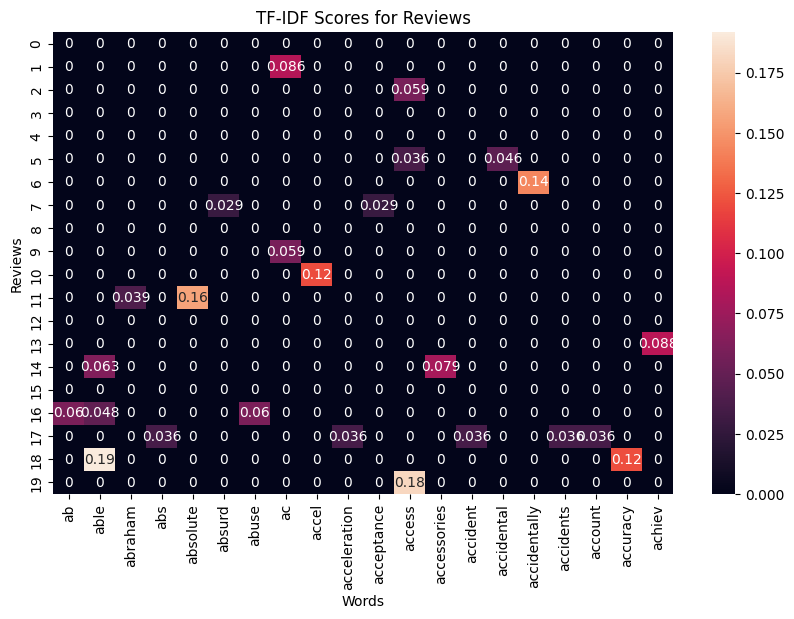

In [203]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(word_df.iloc[:20, :20], annot=True)
plt.title("TF-IDF Scores for Reviews")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()

## Word Embeddings

In [205]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.8 MB/s eta 0:00:0000:0100:01


In [206]:
import gensim.downloader as api
model = api.load('glove-wiki-gigaword-50')
print(type(model))
print(model['movie'])

[==================================================] 100.0% 66.0/66.0MB downloaded
<class 'gensim.models.keyedvectors.KeyedVectors'>
[ 0.30824   0.17223  -0.23339   0.023105  0.28522   0.23076  -0.41048
 -1.0035   -0.2072    1.4327   -0.80684   0.68954  -0.43648   1.1069
  1.6107   -0.31966   0.47744   0.79395  -0.84374   0.064509  0.90251
  0.78609   0.29699   0.76057   0.433    -1.5032   -1.6423    0.30256
  0.30771  -0.87057   2.4782   -0.025852  0.5013   -0.38593  -0.15633
  0.45522   0.04901  -0.42599  -0.86402  -1.3076   -0.29576   1.209
 -0.3127   -0.72462  -0.80801   0.082667  0.26738  -0.98177  -0.32147
  0.99823 ]


Example

In [211]:
# Compute similarity between "king" and "queen"
similarity_score = model.similarity('king','queen')

print(similarity_score)

# Get top 10 most similar words to "computer"
similar_words = model.most_similar('computer',topn=10)

print(similar_words)

0.7839043
[('computers', 0.9165045022964478), ('software', 0.8814992904663086), ('technology', 0.852556049823761), ('electronic', 0.812586784362793), ('internet', 0.8060455322265625), ('computing', 0.802603542804718), ('devices', 0.8016185760498047), ('digital', 0.7991793751716614), ('applications', 0.7912740707397461), ('pc', 0.7883159518241882)]


In [212]:
from sklearn.decomposition import PCA

In [213]:
words = vectorizer.get_feature_names_out()
word_vectors = np.array([model[word] for word in words if word in model])
word_vectors

array([[-0.50633  ,  0.42662  ,  0.44752  , ...,  1.0677   ,  0.036386 ,
         0.53565  ],
       [ 0.86454  , -0.39089  ,  0.98069  , ..., -0.13879  , -0.22527  ,
         0.23315  ],
       [-0.0066393,  0.84743  ,  0.34405  , ..., -0.48629  , -0.69015  ,
         0.37428  ],
       ...,
       [-1.2192   ,  0.32987  ,  0.95971  , ...,  0.089147 ,  0.059499 ,
         0.43447  ],
       [-0.22397  , -0.0033712,  0.60372  , ..., -0.41077  ,  0.8399   ,
        -1.0556   ],
       [ 0.17034  ,  0.35122  ,  1.5457   , ..., -0.40952  , -0.40912  ,
         0.53032  ]], dtype=float32)

Text(0.5, 1.0, 'Word Vectors in 2D Space')

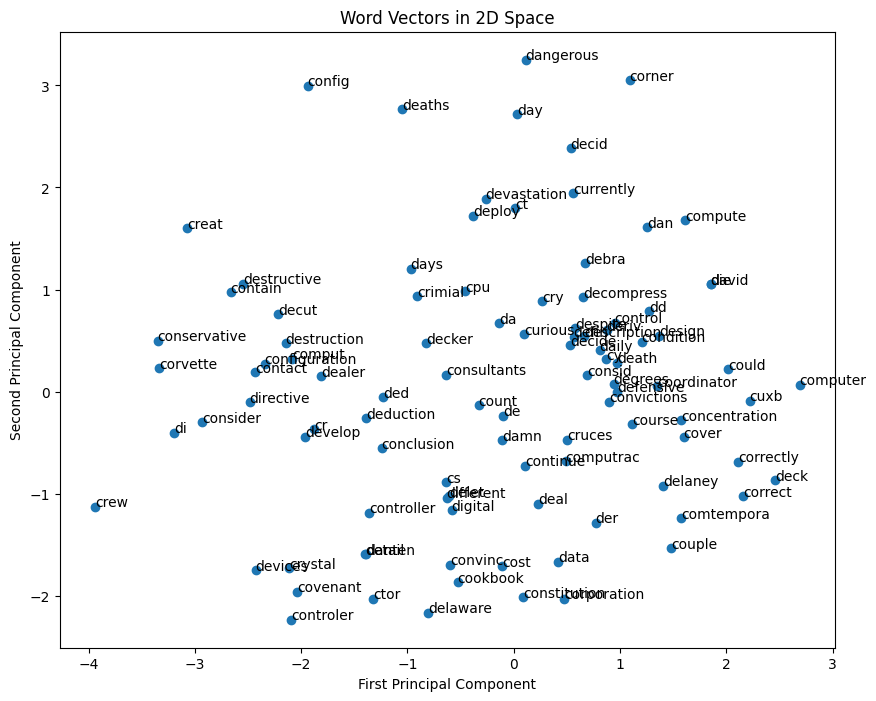

In [226]:
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)
plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_2d[:, 0][250:350], word_vectors_2d[:, 1][250:350])
for word, (x, y) in zip(words[250:350], word_vectors_2d[250:350]):
    plt.annotate(word,(x, y))
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Word Vectors in 2D Space')